In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
print(tf.__version__)
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images.shape

2.20.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

### Pre-processing

In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0
train_label_onehot = tf.keras.utils.to_categorical(train_labels)
test_label_onehot = tf.keras.utils.to_categorical(test_labels)
train_label_onehot.shape

(60000, 10)

### Shallow Fully Connected Neural Network

In [4]:
model_shallow = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # 784
    tf.keras.layers.Dense(392, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(98, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])
model_shallow.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │         4,851 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,405 (1.56 MB)

 Trainable params: 409,405 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model_shallow.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [6]:
history_shallow = model_shallow.fit(
    train_images, 
    train_label_onehot, 
    epochs=10,
    validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8066 - loss: 0.5357 - val_accuracy: 0.8258 - val_loss: 0.4619
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8577 - loss: 0.3889 - val_accuracy: 0.8635 - val_loss: 0.3758
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8707 - loss: 0.3490 - val_accuracy: 0.8744 - val_loss: 0.3431
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8800 - loss: 0.3252 - val_accuracy: 0.8778 - val_loss: 0.3395
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8868 - loss: 0.3044 - val_accuracy: 0.8694 - val_loss: 0.3763
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8918 - loss: 0.2898 - val_accuracy: 0.8817 - val_loss: 0.3399
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8967 - loss: 0.2765 - val_accuracy: 0.8808 - val_loss: 0.3416
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9013 - loss: 0.2620 

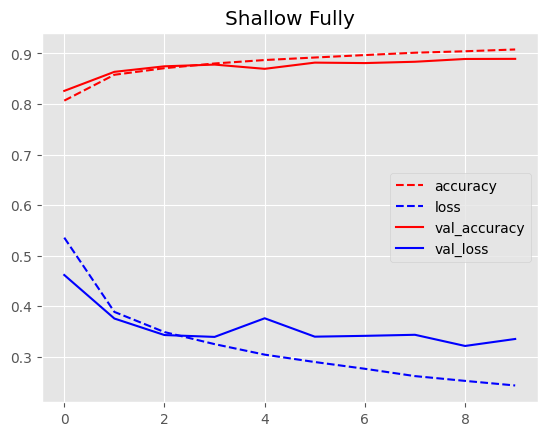

In [7]:
def plot_acc_val(history, title=''):
    plt.plot(history.history['accuracy'], label='accuracy', color='r', linestyle='--')
    plt.plot(history.history['loss'], label='loss', color='b', linestyle='--')
    plt.plot(history.history['val_accuracy'], label='val_accuracy', color='r', linestyle='-')
    plt.plot(history.history['val_loss'], label='val_loss', color='b', linestyle='-')
    plt.title(title)
    plt.legend()
    
plot_acc_val(history_shallow, 'Shallow Fully')

In [8]:
model_shallow.evaluate(test_images, test_label_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8778 - loss: 0.3694


[0.3693884313106537, 0.8777999877929688]

### Deep Fully Connected Neural Network

In [9]:
model_deep = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(49, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])
model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 196)            │       153,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 196)            │        38,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 49)             │         9,653 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 49)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,385 (1.57 MB)

 Trainable params: 410,385 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_deep.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [11]:
history_deep = model_deep.fit(
    train_images, 
    train_label_onehot, 
    epochs=10,
    validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6927 - loss: 0.7803 - val_accuracy: 0.7641 - val_loss: 0.6570
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8188 - loss: 0.5097 - val_accuracy: 0.8373 - val_loss: 0.4644
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8446 - loss: 0.4520 - val_accuracy: 0.8224 - val_loss: 0.4902
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8566 - loss: 0.4189 - val_accuracy: 0.8487 - val_loss: 0.4291
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8647 - loss: 0.3937 - val_accuracy: 0.8652 - val_loss: 0.3983
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8677 - loss: 0.3856 - val_accuracy: 0.8560 - val_loss: 0.4140
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8692 - loss: 0.3768 - val_accuracy: 0.8646 - val_loss: 0.3901
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8793 - loss: 0.3473

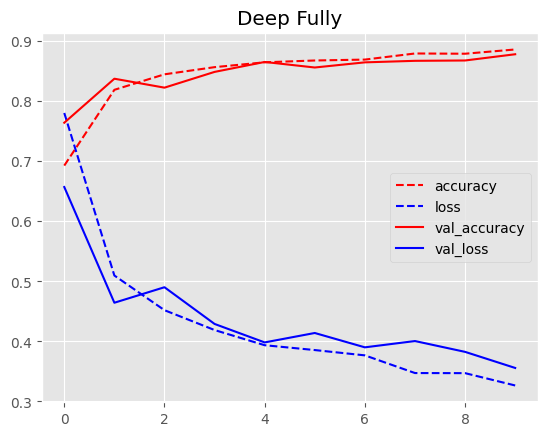

In [12]:
plot_acc_val(history_deep, 'Deep Fully')

In [13]:
model_deep.evaluate(test_images, test_label_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8684 - loss: 0.3793


[0.3792894184589386, 0.868399977684021]

### Convolutional Neural Network（CNN）

In [14]:
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=7,
        kernel_size=(7, 7),
        activation='relu',
        input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(392, activation='relu'),
    tf.keras.layers.Dense(196, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 7)      │           350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 7)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 847)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 392)            │       332,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,764 (1.57 MB)

 Trainable params: 411,764 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])


In [16]:
history_cnn = model_cnn.fit(
    train_images,
    train_label_onehot,
    epochs=10,
    validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8287 - loss: 0.4757 - val_accuracy: 0.8685 - val_loss: 0.3607
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8775 - loss: 0.3317 - val_accuracy: 0.8804 - val_loss: 0.3300
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8937 - loss: 0.2834 - val_accuracy: 0.8893 - val_loss: 0.2985
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9060 - loss: 0.2480 - val_accuracy: 0.8835 - val_loss: 0.3160
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9177 - loss: 0.2200 - val_accuracy: 0.8967 - val_loss: 0.2958
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9262 - loss: 0.1930 - val_accuracy: 0.8994 - val_loss: 0.2924
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9345 - loss: 0.1720 - val_accuracy: 0.8986 - val_loss: 0.3063
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9431 -

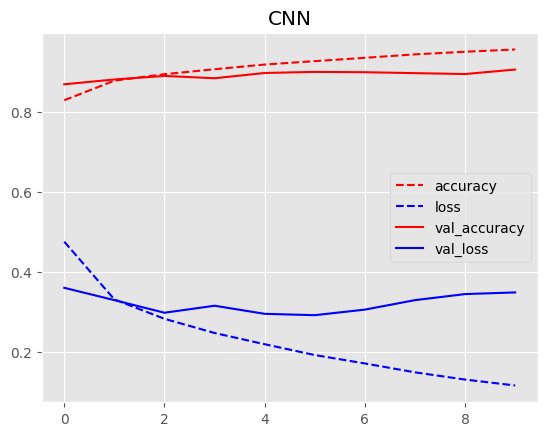

In [17]:
plot_acc_val(history_cnn, 'CNN')

In [18]:
model_cnn.evaluate(test_images, test_label_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8999 - loss: 0.3929


[0.3928588330745697, 0.8999000191688538]